In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Isolation Tree
from sklearn.ensemble import IsolationForest
#Pre-defined Dataset UCI
from ucimlrepo import fetch_ucirepo

In [9]:
#Load the Dataset
air_quality=fetch_ucirepo(id=360)

In [15]:
data=air_quality.data.features
data.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [16]:
df=data[['CO(GT)','C6H6(GT)','NOx(GT)','NO2(GT)']]
df.head()

,CO(GT),C6H6(GT),NOx(GT),NO2(GT)
0,2.6,11.9,166,113
1,2.0,9.4,103,92
2,2.2,9.0,131,114
3,2.2,9.2,172,122
4,1.6,6.5,131,116


In [20]:
print(df.dtypes)
df.isnull().sum()
df.shape

CO(GT)      float64
C6H6(GT)    float64
NOx(GT)       int64
NO2(GT)       int64
dtype: object


(9357, 4)

In [22]:
# parameters for Isolation Tree
n_estimators=100 # number of trees in the forest
contamination=0.01 # percentage of outliers in the data
sample_size=256

In [23]:
model=IsolationForest(n_estimators=n_estimators,
                      contamination=contamination,
                      max_samples=sample_size,
                      random_state=42)

In [ ]:
model.fit(df)

# Predict Anomalies
anomaly_labels=model.predict(df)

#Anomaly labels will be -1 for anomalies and 1 for normal data points

# Add anamoly labels to the dataframe
df['anomaly']=anomaly_labels

C:\Users\728sa\AppData\Local\Temp\ipykernel_15268\298699702.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['anomaly']=anomaly_labels


In [25]:
df['anomaly'].value_counts()

anomaly
 1    9263
-1      94
Name: count, dtype: int64

In [27]:
normal=df[df['anomaly']==1]
anomaly=df[df['anomaly']==-1]

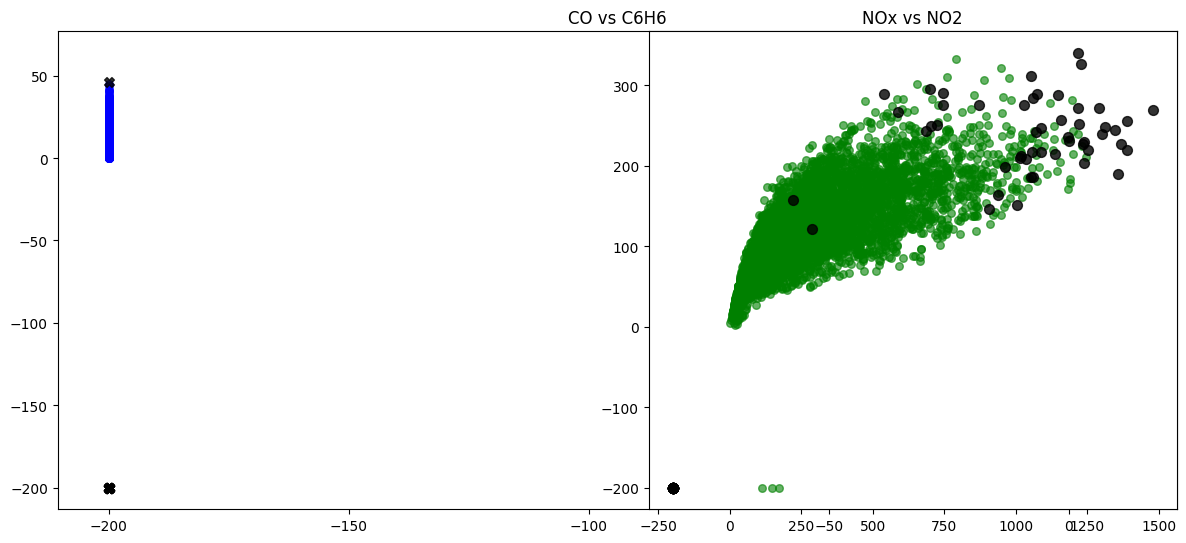

In [33]:
plt.figure(figsize=(12,6))
plt.subplot(1,1,1)
plt.scatter(normal['CO(GT)'],normal['C6H6(GT)'],c='blue',label='Normal',alpha=0.6,s=30)
plt.scatter(anomaly['CO(GT)'],anomaly['C6H6(GT)'],c='black',label='Anomaly',s=50,alpha=0.8,marker='X')
plt.title('CO vs C6H6')

plt.subplot(1,2,2)
plt.scatter(normal['NOx(GT)'],normal['NO2(GT)'],c='green',alpha=0.6,s=30)
plt.scatter(anomaly['NOx(GT)'],anomaly['NO2(GT)'],c='black',alpha=0.8,s=50)
plt.title('NOx vs NO2')
plt.tight_layout()
plt.show()

In [38]:
import joblib 
model_path='C:\Tekworks\Feature_Selection\Isolation_Forest_model.pkl'
joblib.dump(model,model_path)

['C:\\Tekworks\\Feature_Selection\\Isolation_Forest_model.pkl']

In [39]:
csv_path="air_quality_anomalies.csv"
df.to_csv(csv_path,index=False)
print("Data with anomaly labels saved to: ",csv_path)

Data with anomaly labels saved to:  air_quality_anomalies.csv
